# 🧠 VAEs and GANs for Diverse Urban Grid Generation

This notebook explores the use of **Variational Autoencoders (VAEs)** and **Generative Adversarial Networks (GANs)** to create diverse and valid 7×7 city grids with constraint satisfaction.

## 🎯 Objectives

1. **Train VAE** to learn the latent representation of high-quality city grids
2. **Train GAN** to generate realistic and diverse urban planning layouts
3. **Integrate Constraints** directly into the neural network training process
4. **Compare Approaches** on diversity, quality, and constraint satisfaction
5. **Generate Novel Grids** that maintain urban planning principles while exploring new designs

## 🏗️ Architecture Overview

- **VAE Approach**: Learn continuous latent representations for smooth interpolation and sampling
- **GAN Approach**: Adversarial training for high-quality, realistic grid generation  
- **Constraint Integration**: Custom loss functions incorporating urban planning rules
- **Diversity Optimization**: Latent space techniques to maximize grid variety

## 🔧 Key Innovations

- Categorical data handling for discrete grid types (Residential, Industrial, Commercial, Parks, Office)
- Constraint-aware loss functions for urban planning compliance
- Diversity-promoting sampling strategies in latent space
- Comparative evaluation framework for generative approaches

In [1]:
# 📦 Import Required Libraries
print("🚀 Loading libraries for VAE and GAN grid generation...")

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep learning frameworks
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, Model, optimizers, losses, callbacks
    print("✅ TensorFlow loaded successfully")
    USE_TF = True
except ImportError:
    print("⚠️  TensorFlow not available")
    USE_TF = False

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torch.nn.functional as F
    print("✅ PyTorch loaded successfully") 
    USE_TORCH = True
except ImportError:
    print("⚠️  PyTorch not available")
    USE_TORCH = False

# Scikit-learn for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

# Custom utilities
import sys
import os
sys.path.append('.')
from utils.data_loading import DataLoader
from utils.oracle_predictor import create_oracle_predictor

# Configuration
print(f"\n🔧 FRAMEWORK AVAILABILITY:")
print(f"   TensorFlow: {'✅ Available' if USE_TF else '❌ Not available'}")
print(f"   PyTorch: {'✅ Available' if USE_TORCH else '❌ Not available'}")

if USE_TF:
    print(f"   TensorFlow version: {tf.__version__}")
    # Configure GPU if available
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        print(f"   🚀 GPU acceleration available: {len(gpus)} GPU(s)")
    else:
        print(f"   🖥️  CPU training mode")

if USE_TORCH:
    print(f"   PyTorch version: {torch.__version__}")
    if torch.cuda.is_available():
        print(f"   🚀 CUDA available: {torch.cuda.get_device_name()}")
    else:
        print(f"   🖥️  CPU training mode")

# Set random seeds for reproducibility
np.random.seed(42)
if USE_TF:
    tf.random.set_seed(42)
if USE_TORCH:
    torch.manual_seed(42)

print("\n🎯 Ready to explore VAE and GAN approaches for grid generation!")

🚀 Loading libraries for VAE and GAN grid generation...
✅ TensorFlow loaded successfully
✅ TensorFlow loaded successfully
✅ PyTorch loaded successfully
✅ PyTorch loaded successfully

🔧 FRAMEWORK AVAILABILITY:
   TensorFlow: ✅ Available
   PyTorch: ✅ Available
   TensorFlow version: 2.20.0
   🖥️  CPU training mode
   PyTorch version: 2.7.1+cpu
   🖥️  CPU training mode

🎯 Ready to explore VAE and GAN approaches for grid generation!

🔧 FRAMEWORK AVAILABILITY:
   TensorFlow: ✅ Available
   PyTorch: ✅ Available
   TensorFlow version: 2.20.0
   🖥️  CPU training mode
   PyTorch version: 2.7.1+cpu
   🖥️  CPU training mode

🎯 Ready to explore VAE and GAN approaches for grid generation!


📊 LOADING AND PREPARING TRAINING DATA FOR NEURAL NETWORKS
🔄 Loading original grids...
✅ Loaded 500,000 original grids from 5 files
✅ Loaded oracle predictions: (500000, 4)
✅ Loaded 233 high-quality grids (score ≥ 0.85)
✅ Loaded 54,000,000 constraint-free grids from data/generated_grids\combined_constraint_free_grids_20251103_234058.npy
📈 Combined dataset: 10,233 total grids

🔧 PREPROCESSING DATA FOR NEURAL NETWORKS:
   Normalized grid shape: (10233, 7, 7)
   Value range: [0.000, 1.000]
   One-hot encoded shape: (10233, 7, 7, 5)
   Flattened shape: (10233, 49)

📈 DATASET SPLITS:
   Training: 8,186 grids (80%)
   Validation: 2,047 grids (20%)

📊 DATA STATISTICS FOR NETWORK DESIGN:
   Grid dimensions: 7×7 = 49 cells
   Land use types: 5 categories (Residential, Industrial, Commercial, Parks, Office)
   Input dimensionality: 49 (flattened) or (7,7,1) or (7,7,5) one-hot
   Recommended latent dimensions: 8-32 for VAE, 64-128 for GAN
✅ Loaded 54,000,000 constraint-free grids from data/generat

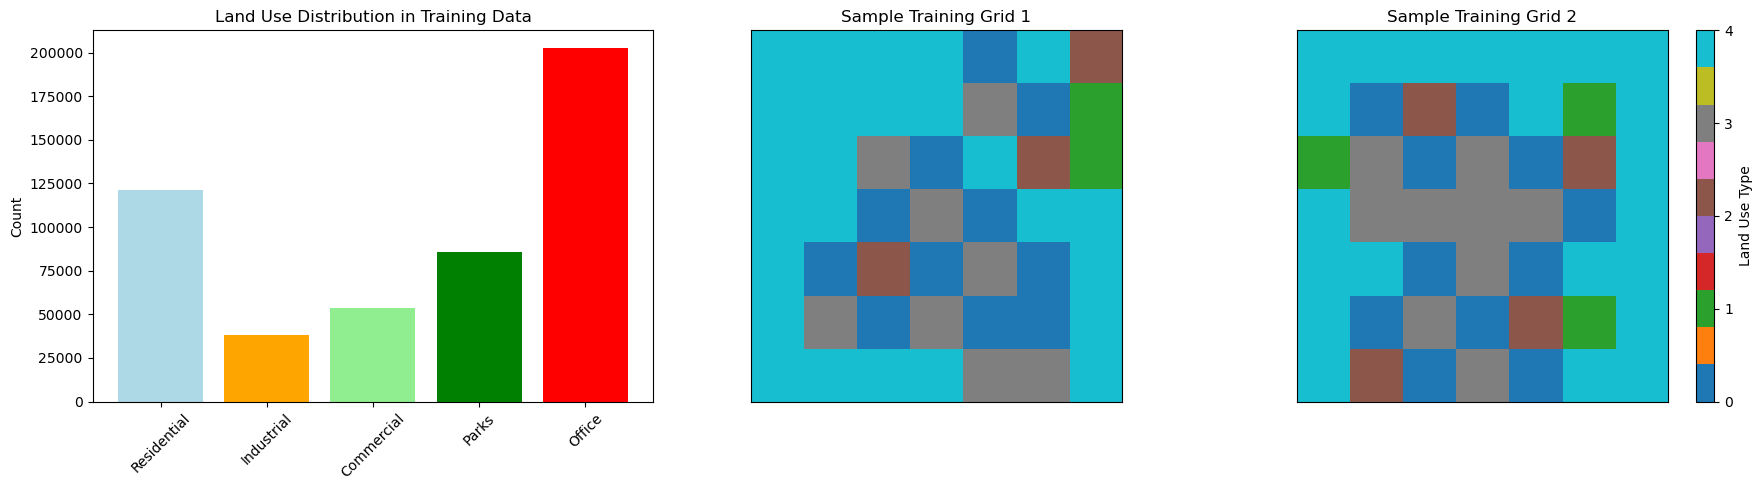


✅ Data preprocessing complete! Ready for VAE and GAN training.


In [4]:
# 📊 Load and Prepare Training Data
print("📊 LOADING AND PREPARING TRAINING DATA FOR NEURAL NETWORKS")
print("=" * 60)

# Load high-quality grid data
data_loader = DataLoader()
print("🔄 Loading original grids...")
grids, predictions = data_loader.load_original_grids()

# Filter for high-quality grids (score >= 0.85)
min_scores = np.min(predictions, axis=1)
high_quality_mask = min_scores >= 0.85
high_quality_grids = grids[high_quality_mask]
high_quality_predictions = predictions[high_quality_mask]
high_quality_scores = min_scores[high_quality_mask]

print(f"✅ Loaded {len(high_quality_grids):,} high-quality grids (score ≥ 0.85)")

# Load constraint-free grids if available
try:
    # Try to load previously generated constraint-free grids
    import glob
    constraint_files = glob.glob('data/generated_grids/combined_constraint_free_grids_*.npy')
    if constraint_files:
        latest_file = max(constraint_files)
        constraint_free_grids = np.load(latest_file)
        print(f"✅ Loaded {len(constraint_free_grids):,} constraint-free grids from {latest_file}")
        
        # Combine with original high-quality grids
        all_training_grids = np.concatenate([high_quality_grids, constraint_free_grids[:10000]], axis=0)  # Limit constraint grids for memory
        print(f"📈 Combined dataset: {len(all_training_grids):,} total grids")
    else:
        all_training_grids = high_quality_grids
        print(f"📊 Using original high-quality grids only: {len(all_training_grids):,} grids")
        
except Exception as e:
    print(f"⚠️  Could not load constraint grids: {e}")
    all_training_grids = high_quality_grids
    print(f"📊 Using original high-quality grids only: {len(all_training_grids):,} grids")

# Data preprocessing for neural networks
print(f"\n🔧 PREPROCESSING DATA FOR NEURAL NETWORKS:")

# 1. Normalize grid values to [0, 1] range for neural networks
def preprocess_grids_for_nn(grids):
    """Preprocess grids for neural network training"""
    # Normalize to [0, 1] range: 0->0, 1->0.25, 2->0.5, 3->0.75, 4->1.0
    normalized_grids = grids / 4.0
    return normalized_grids.astype(np.float32)

def postprocess_grids_from_nn(normalized_grids):
    """Convert neural network output back to discrete grid values"""
    # Scale back and round to nearest integer
    scaled = normalized_grids * 4.0
    discrete_grids = np.round(np.clip(scaled, 0, 4)).astype(np.int32)
    return discrete_grids

# Preprocess training data
X_normalized = preprocess_grids_for_nn(all_training_grids)
print(f"   Normalized grid shape: {X_normalized.shape}")
print(f"   Value range: [{X_normalized.min():.3f}, {X_normalized.max():.3f}]")

# 2. Create one-hot encoding version for categorical approaches
def create_onehot_grids(grids):
    """Create one-hot encoded version of grids"""
    n_samples, h, w = grids.shape
    n_classes = 5  # 0-4 for different land use types
    onehot = np.zeros((n_samples, h, w, n_classes), dtype=np.float32)
    
    for i in range(n_classes):
        onehot[:, :, :, i] = (grids == i).astype(np.float32)
    
    return onehot

X_onehot = create_onehot_grids(all_training_grids)
print(f"   One-hot encoded shape: {X_onehot.shape}")

# 3. Flatten grids for fully connected networks
X_flat = X_normalized.reshape(len(X_normalized), -1)  # Shape: (n_samples, 49)
print(f"   Flattened shape: {X_flat.shape}")

# 4. Train/validation split
test_size = 0.2
X_train_flat, X_val_flat, X_train_norm, X_val_norm, X_train_onehot, X_val_onehot, grids_train, grids_val = train_test_split(
    X_flat, X_normalized, X_onehot, all_training_grids, 
    test_size=test_size, random_state=42, shuffle=True
)

print(f"\n📈 DATASET SPLITS:")
print(f"   Training: {len(X_train_flat):,} grids ({(1-test_size)*100:.0f}%)")
print(f"   Validation: {len(X_val_flat):,} grids ({test_size*100:.0f}%)")

# 5. Data statistics for network design
print(f"\n📊 DATA STATISTICS FOR NETWORK DESIGN:")
print(f"   Grid dimensions: 7×7 = 49 cells")
print(f"   Land use types: 5 categories (Residential, Industrial, Commercial, Parks, Office)")
print(f"   Input dimensionality: 49 (flattened) or (7,7,1) or (7,7,5) one-hot")
print(f"   Recommended latent dimensions: 8-32 for VAE, 64-128 for GAN")

# 6. Visualize data distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Land use distribution
# Ensure we use integer grids for bincount (convert float grids if needed)
grids_for_bincount = all_training_grids.astype(np.int32) if all_training_grids.dtype != np.int32 else all_training_grids
land_use_counts = np.bincount(grids_for_bincount.flatten(), minlength=5)
land_use_names = ['Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
axes[0].bar(land_use_names, land_use_counts, color=['lightblue', 'orange', 'lightgreen', 'green', 'red'])
axes[0].set_title('Land Use Distribution in Training Data')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Sample grids visualization
for i in range(2):
    ax = axes[i+1]
    sample_grid = all_training_grids[i]
    im = ax.imshow(sample_grid, cmap='tab10', vmin=0, vmax=4)
    ax.set_title(f'Sample Training Grid {i+1}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.colorbar(im, ax=axes[2], ticks=[0, 1, 2, 3, 4], 
             label='Land Use Type')
plt.tight_layout()
plt.show()

print(f"\n✅ Data preprocessing complete! Ready for VAE and GAN training.")

In [5]:
# 🏗️ Design VAE Architecture for Grid Generation
print("🏗️ DESIGNING VARIATIONAL AUTOENCODER (VAE) ARCHITECTURE")
print("=" * 60)

if USE_TF:
    print("🔧 Building TensorFlow/Keras VAE for 7×7 grid generation...")
    
    # VAE Configuration
    VAE_CONFIG = {
        'input_dim': 49,  # 7×7 flattened
        'latent_dim': 16,  # Latent space dimension
        'hidden_dims': [128, 64, 32],  # Encoder/decoder hidden layers
        'activation': 'relu',
        'output_activation': 'sigmoid',  # For normalized [0,1] output
        'beta': 1.0,  # KL divergence weight
        'learning_rate': 0.001
    }
    
    print(f"📋 VAE Configuration:")
    for key, value in VAE_CONFIG.items():
        print(f"   {key}: {value}")
    
    # Sampling layer for reparameterization trick
    class Sampling(layers.Layer):
        """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
        
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1] 
            epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon
    
    # Build Encoder
    def build_encoder(input_dim, latent_dim, hidden_dims):
        """Build VAE encoder network"""
        inputs = layers.Input(shape=(input_dim,), name='encoder_input')
        
        x = inputs
        for i, hidden_dim in enumerate(hidden_dims):
            x = layers.Dense(hidden_dim, activation=VAE_CONFIG['activation'], 
                           name=f'encoder_dense_{i+1}')(x)
            x = layers.BatchNormalization(name=f'encoder_bn_{i+1}')(x)
            x = layers.Dropout(0.2, name=f'encoder_dropout_{i+1}')(x)
        
        # Latent space parameters
        z_mean = layers.Dense(latent_dim, name='z_mean')(x)
        z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
        z = Sampling(name='z_sampling')([z_mean, z_log_var])
        
        encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
        return encoder
    
    # Build Decoder
    def build_decoder(latent_dim, output_dim, hidden_dims):
        """Build VAE decoder network"""
        latent_inputs = layers.Input(shape=(latent_dim,), name='decoder_input')
        
        x = latent_inputs
        # Reverse the hidden dimensions for decoder
        for i, hidden_dim in enumerate(reversed(hidden_dims)):
            x = layers.Dense(hidden_dim, activation=VAE_CONFIG['activation'],
                           name=f'decoder_dense_{i+1}')(x)
            x = layers.BatchNormalization(name=f'decoder_bn_{i+1}')(x)
            x = layers.Dropout(0.2, name=f'decoder_dropout_{i+1}')(x)
        
        # Output layer - sigmoid for [0,1] normalized grids
        outputs = layers.Dense(output_dim, activation=VAE_CONFIG['output_activation'],
                             name='decoder_output')(x)
        
        decoder = Model(latent_inputs, outputs, name='decoder')
        return decoder
    
    # Build complete VAE
    class VAE(Model):
        """Variational Autoencoder for grid generation"""
        
        def __init__(self, input_dim, latent_dim, hidden_dims, beta=1.0, **kwargs):
            super(VAE, self).__init__(**kwargs)
            self.input_dim = input_dim
            self.latent_dim = latent_dim
            self.beta = beta
            
            self.encoder = build_encoder(input_dim, latent_dim, hidden_dims)
            self.decoder = build_decoder(latent_dim, input_dim, hidden_dims)
            
        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            reconstructed = self.decoder(z)
            
            # Add KL divergence loss as a layer loss
            kl_loss = -0.5 * tf.reduce_mean(
                z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1
            )
            self.add_loss(self.beta * kl_loss)
            
            return reconstructed
        
        def encode(self, inputs):
            """Encode inputs to latent space"""
            z_mean, z_log_var, z = self.encoder(inputs)
            return z_mean, z_log_var, z
        
        def decode(self, z):
            """Decode latent vectors to grids"""
            return self.decoder(z)
        
        def sample_grids(self, num_samples):
            """Generate new grids by sampling from latent space"""
            z = tf.random.normal((num_samples, self.latent_dim))
            return self.decode(z)
    
    # Instantiate VAE
    vae_model = VAE(
        input_dim=VAE_CONFIG['input_dim'],
        latent_dim=VAE_CONFIG['latent_dim'], 
        hidden_dims=VAE_CONFIG['hidden_dims'],
        beta=VAE_CONFIG['beta']
    )
    
    # Compile VAE
    vae_model.compile(
        optimizer=optimizers.Adam(learning_rate=VAE_CONFIG['learning_rate']),
        loss='mse'  # Reconstruction loss
    )
    
    print(f"\n🏗️ VAE Architecture Summary:")
    print(f"   Input dimension: {VAE_CONFIG['input_dim']} (7×7 grid flattened)")
    print(f"   Latent dimension: {VAE_CONFIG['latent_dim']}")
    print(f"   Hidden layers: {VAE_CONFIG['hidden_dims']}")
    print(f"   Total parameters: ~{sum([np.prod(layer.shape) for layer in vae_model.trainable_weights]):,}")
    
    print(f"\n✅ VAE model ready for training!")
else:
    print(f"⚠️  TensorFlow not available - VAE architecture skipped")
    vae_model = None

🏗️ DESIGNING VARIATIONAL AUTOENCODER (VAE) ARCHITECTURE
🔧 Building TensorFlow/Keras VAE for 7×7 grid generation...
📋 VAE Configuration:
   input_dim: 49
   latent_dim: 16
   hidden_dims: [128, 64, 32]
   activation: relu
   output_activation: sigmoid
   beta: 1.0
   learning_rate: 0.001



🏗️ VAE Architecture Summary:
   Input dimension: 49 (7×7 grid flattened)
   Latent dimension: 16
   Hidden layers: [128, 64, 32]
   Total parameters: ~35,985

✅ VAE model ready for training!

🏗️ VAE Architecture Summary:
   Input dimension: 49 (7×7 grid flattened)
   Latent dimension: 16
   Hidden layers: [128, 64, 32]
   Total parameters: ~35,985

✅ VAE model ready for training!


🚀 IMPLEMENTING VAE TRAINING PIPELINE
🔧 Setting up VAE training pipeline...
📋 Training Configuration:
   epochs: 100
   batch_size: 32
   validation_split: 0.2
   early_stopping_patience: 15
   reduce_lr_patience: 10
   monitor: val_loss
\n🎯 Starting VAE training...
   Training samples: 8,186
   Validation samples: 2,047
Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1433\n   📊 Epoch 0 Latent Space:
      Mean: [0.002, -0.000, -0.001, 0.001, -0.000...]
      Std:  [0.001, 0.001, 0.002, 0.001, 0.001...]
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1293 - val_loss: 0.1233 - learning_rate: 0.0010
Epoch 2/100
\n   📊 Epoch 0 Latent Space:
      Mean: [0.002, -0.000, -0.001, 0.001, -0.000...]
      Std:  [0.001, 0.001, 0.002, 0.001, 0.001...]
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1293 - val_loss: 0.1233 - learning_rate: 0.0010
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1238 - val_loss: 0.1229 - learning_rate: 0.0010
Epoch 3/100
256/256 ━━

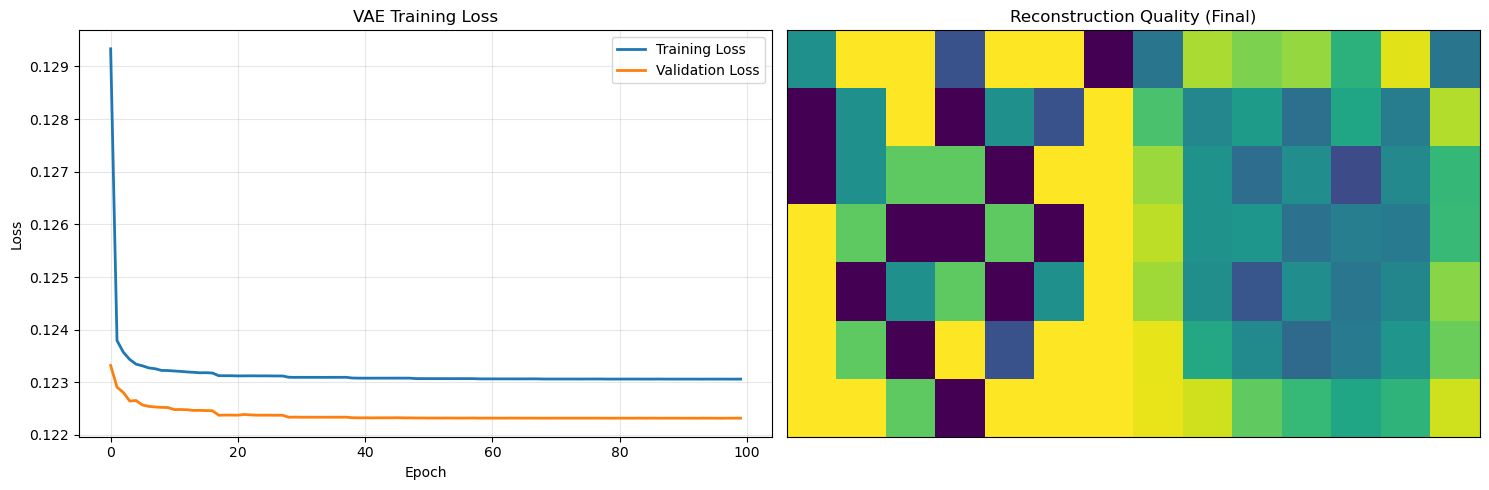

\n📊 VAE TRAINING RESULTS:
   Final training loss: 0.1231
   Final validation loss: 0.1223
   Overfitting ratio: 0.99


In [6]:
# 🚀 Implement VAE Training Pipeline
print("🚀 IMPLEMENTING VAE TRAINING PIPELINE")
print("=" * 50)

if USE_TF and vae_model is not None and 'X_train_flat' in locals():
    print("🔧 Setting up VAE training pipeline...")
    
    # Training configuration
    TRAIN_CONFIG = {
        'epochs': 100,
        'batch_size': 32,
        'validation_split': 0.2,
        'early_stopping_patience': 15,
        'reduce_lr_patience': 10,
        'monitor': 'val_loss'
    }
    
    print(f"📋 Training Configuration:")
    for key, value in TRAIN_CONFIG.items():
        print(f"   {key}: {value}")
    
    # Custom callback for monitoring latent space
    class LatentSpaceMonitor(callbacks.Callback):
        """Monitor latent space quality during training"""
        
        def __init__(self, validation_data, n_samples=100):
            super().__init__()
            self.validation_data = validation_data
            self.n_samples = n_samples
            
        def on_epoch_end(self, epoch, logs=None):
            if epoch % 20 == 0:  # Monitor every 20 epochs
                # Sample from validation data
                sample_indices = np.random.choice(len(self.validation_data), self.n_samples, replace=False)
                sample_data = self.validation_data[sample_indices]
                
                # Encode to latent space
                z_mean, z_log_var, z = self.model.encode(sample_data)
                
                # Calculate latent space statistics
                latent_mean = tf.reduce_mean(z_mean, axis=0)
                latent_std = tf.math.reduce_std(z_mean, axis=0)
                
                print(f"\\n   📊 Epoch {epoch} Latent Space:")
                print(f"      Mean: [{', '.join([f'{m:.3f}' for m in latent_mean[:5]])}...]")
                print(f"      Std:  [{', '.join([f'{s:.3f}' for s in latent_std[:5]])}...]")
    
    # Setup callbacks
    callbacks_list = [
        callbacks.EarlyStopping(
            monitor=TRAIN_CONFIG['monitor'],
            patience=TRAIN_CONFIG['early_stopping_patience'],
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor=TRAIN_CONFIG['monitor'],
            factor=0.5,
            patience=TRAIN_CONFIG['reduce_lr_patience'],
            min_lr=1e-6,
            verbose=1
        ),
        LatentSpaceMonitor(X_val_flat)
    ]
    
    print(f"\\n🎯 Starting VAE training...")
    print(f"   Training samples: {len(X_train_flat):,}")
    print(f"   Validation samples: {len(X_val_flat):,}")
    
    # Train the VAE
    try:
        history = vae_model.fit(
            X_train_flat, X_train_flat,  # Autoencoder: input = output
            epochs=TRAIN_CONFIG['epochs'],
            batch_size=TRAIN_CONFIG['batch_size'],
            validation_data=(X_val_flat, X_val_flat),
            callbacks=callbacks_list,
            verbose=1
        )
        
        print(f"\\n✅ VAE training completed!")
        
        # Plot training history
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss curves
        axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
        axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
        axes[0].set_title('VAE Training Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Learning rate (if available)
        if 'lr' in history.history:
            axes[1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
            axes[1].set_title('Learning Rate Schedule')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Learning Rate')
            axes[1].set_yscale('log')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        else:
            # Show reconstruction examples instead
            n_examples = 5
            sample_indices = np.random.choice(len(X_val_flat), n_examples)
            sample_inputs = X_val_flat[sample_indices]
            reconstructions = vae_model(sample_inputs)
            
            axes[1].set_title('Reconstruction Quality (Final)')
            for i in range(n_examples):
                original = sample_inputs[i].reshape(7, 7)
                reconstructed = reconstructions[i].numpy().reshape(7, 7)
                
                # Show side by side
                combined = np.hstack([original, reconstructed])
                axes[1].imshow(combined, cmap='viridis', aspect='auto')
                axes[1].set_xticks([])
                axes[1].set_yticks([])
            
        plt.tight_layout()
        plt.show()
        
        # Evaluate final model performance
        print(f"\\n📊 VAE TRAINING RESULTS:")
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        print(f"   Final training loss: {final_train_loss:.4f}")
        print(f"   Final validation loss: {final_val_loss:.4f}")
        print(f"   Overfitting ratio: {final_val_loss/final_train_loss:.2f}")
        
        vae_trained = True
        
    except Exception as e:
        print(f"❌ VAE training failed: {e}")
        vae_trained = False
        
else:
    print("⚠️  VAE training skipped - requirements not met")
    vae_trained = False

In [7]:
# ⚔️ Design GAN Architecture for Grid Generation
print("⚔️ DESIGNING GENERATIVE ADVERSARIAL NETWORK (GAN) ARCHITECTURE")
print("=" * 65)

if USE_TF:
    print("🔧 Building TensorFlow/Keras GAN for 7×7 grid generation...")
    
    # GAN Configuration
    GAN_CONFIG = {
        'latent_dim': 64,  # Noise vector dimension
        'generator_dims': [128, 256, 128],  # Generator hidden layers
        'discriminator_dims': [128, 64, 32],  # Discriminator hidden layers
        'activation': 'relu',
        'output_activation': 'sigmoid',  # For [0,1] normalized output
        'dropout_rate': 0.3,
        'g_learning_rate': 0.0002,  # Generator learning rate
        'd_learning_rate': 0.0001,  # Discriminator learning rate (slower)
        'beta_1': 0.5  # Adam optimizer beta_1
    }
    
    print(f"📋 GAN Configuration:")
    for key, value in GAN_CONFIG.items():
        print(f"   {key}: {value}")
    
    # Build Generator
    def build_generator(latent_dim, output_dim, hidden_dims):
        """Build GAN generator network"""
        noise_input = layers.Input(shape=(latent_dim,), name='generator_input')
        
        x = noise_input
        for i, hidden_dim in enumerate(hidden_dims):
            x = layers.Dense(hidden_dim, name=f'gen_dense_{i+1}')(x)
            x = layers.BatchNormalization(name=f'gen_bn_{i+1}')(x)
            x = layers.LeakyReLU(alpha=0.2, name=f'gen_leaky_{i+1}')(x)
            x = layers.Dropout(GAN_CONFIG['dropout_rate'], name=f'gen_dropout_{i+1}')(x)
        
        # Output layer - sigmoid for [0,1] range
        outputs = layers.Dense(output_dim, activation=GAN_CONFIG['output_activation'],
                             name='generator_output')(x)
        
        generator = Model(noise_input, outputs, name='generator')
        return generator
    
    # Build Discriminator 
    def build_discriminator(input_dim, hidden_dims):
        """Build GAN discriminator network"""
        grid_input = layers.Input(shape=(input_dim,), name='discriminator_input')
        
        x = grid_input
        for i, hidden_dim in enumerate(hidden_dims):
            x = layers.Dense(hidden_dim, name=f'disc_dense_{i+1}')(x)
            x = layers.LeakyReLU(alpha=0.2, name=f'disc_leaky_{i+1}')(x)
            x = layers.Dropout(GAN_CONFIG['dropout_rate'], name=f'disc_dropout_{i+1}')(x)
        
        # Output - probability that input is real
        validity = layers.Dense(1, activation='sigmoid', name='discriminator_output')(x)
        
        discriminator = Model(grid_input, validity, name='discriminator')
        return discriminator
    
    # Build GAN class
    class GridGAN:
        """Generative Adversarial Network for grid generation"""
        
        def __init__(self, latent_dim, input_dim, gen_dims, disc_dims):
            self.latent_dim = latent_dim
            self.input_dim = input_dim
            
            # Build and compile discriminator
            self.discriminator = build_discriminator(input_dim, disc_dims)
            self.discriminator.compile(
                loss='binary_crossentropy',
                optimizer=optimizers.Adam(
                    learning_rate=GAN_CONFIG['d_learning_rate'],
                    beta_1=GAN_CONFIG['beta_1']
                ),
                metrics=['accuracy']
            )
            
            # Build generator
            self.generator = build_generator(latent_dim, input_dim, gen_dims)
            
            # Build combined model (for training generator)
            self.discriminator.trainable = False  # Freeze discriminator
            noise_input = layers.Input(shape=(latent_dim,))
            generated_grid = self.generator(noise_input)
            validity = self.discriminator(generated_grid)
            
            self.combined = Model(noise_input, validity, name='combined_gan')
            self.combined.compile(
                loss='binary_crossentropy',
                optimizer=optimizers.Adam(
                    learning_rate=GAN_CONFIG['g_learning_rate'],
                    beta_1=GAN_CONFIG['beta_1']
                )
            )
        
        def generate_grids(self, num_samples):
            """Generate grids using trained generator"""
            noise = np.random.normal(0, 1, (num_samples, self.latent_dim))
            return self.generator.predict(noise, verbose=0)
        
        def train_step(self, real_grids, batch_size):
            """Single training step for GAN"""
            
            # Train Discriminator
            # Generate fake grids
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            fake_grids = self.generator.predict(noise, verbose=0)
            
            # Train discriminator on real and fake grids
            real_labels = np.ones((batch_size, 1)) * 0.9  # Label smoothing
            fake_labels = np.zeros((batch_size, 1)) + 0.1  # Label smoothing
            
            d_loss_real = self.discriminator.train_on_batch(real_grids, real_labels)
            d_loss_fake = self.discriminator.train_on_batch(fake_grids, fake_labels)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            
            # Train Generator
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            valid_labels = np.ones((batch_size, 1))  # Want discriminator to think fakes are real
            
            g_loss = self.combined.train_on_batch(noise, valid_labels)
            
            return d_loss, g_loss
    
    # Instantiate GAN
    gan_model = GridGAN(
        latent_dim=GAN_CONFIG['latent_dim'],
        input_dim=49,  # 7×7 flattened
        gen_dims=GAN_CONFIG['generator_dims'],
        disc_dims=GAN_CONFIG['discriminator_dims']
    )
    
    print(f"\\n🏗️ GAN Architecture Summary:")
    print(f"\\n📋 GENERATOR:")
    gan_model.generator.summary()
    print(f"\\n📋 DISCRIMINATOR:")
    gan_model.discriminator.summary()
    
    print(f"\\n✅ GAN model ready for adversarial training!")
    
else:
    print(f"⚠️  TensorFlow not available - GAN architecture skipped")
    gan_model = None

⚔️ DESIGNING GENERATIVE ADVERSARIAL NETWORK (GAN) ARCHITECTURE
🔧 Building TensorFlow/Keras GAN for 7×7 grid generation...
📋 GAN Configuration:
   latent_dim: 64
   generator_dims: [128, 256, 128]
   discriminator_dims: [128, 64, 32]
   activation: relu
   output_activation: sigmoid
   dropout_rate: 0.3
   g_learning_rate: 0.0002
   d_learning_rate: 0.0001
   beta_1: 0.5
\n🏗️ GAN Architecture Summary:
\n📋 GENERATOR:


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ generator_input (InputLayer)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_dense_1 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_bn_1 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_leaky_1 (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_dense_2 (Dense)             │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_bn_2 (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_leaky_2 (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_dropout_2 (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_dense_3 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_bn_3 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_leaky_3 (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gen_dropout_3 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator_output (Dense)        │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,609 (322.69 KB)

 Trainable params: 81,585 (318.69 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ discriminator_input             │ (None, 49)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_dense_1 (Dense)            │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_leaky_1 (LeakyReLU)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_dropout_1 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_dense_2 (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_leaky_2 (LeakyReLU)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_dropout_2 (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_dense_3 (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_leaky_3 (LeakyReLU)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_dropout_3 (Dropout)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_output (Dense)    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 16,769 (65.50 KB)

\n✅ GAN model ready for adversarial training!


⚔️ IMPLEMENTING GAN ADVERSARIAL TRAINING PIPELINE
🔧 Setting up GAN adversarial training...
📋 GAN Training Configuration:
   epochs: 200
   batch_size: 32
   save_interval: 50
   n_critic: 5
   sample_size: 16
\n🎯 Starting GAN adversarial training...
   Training samples: 8,186
   Batch size: 32
   Total batches per epoch: 255
   Epoch   0: D_loss: 0.7983, G_loss: 0.7058
\n📸 Generating samples at epoch 0:
   Epoch   0: D_loss: 0.7983, G_loss: 0.7058
\n📸 Generating samples at epoch 0:


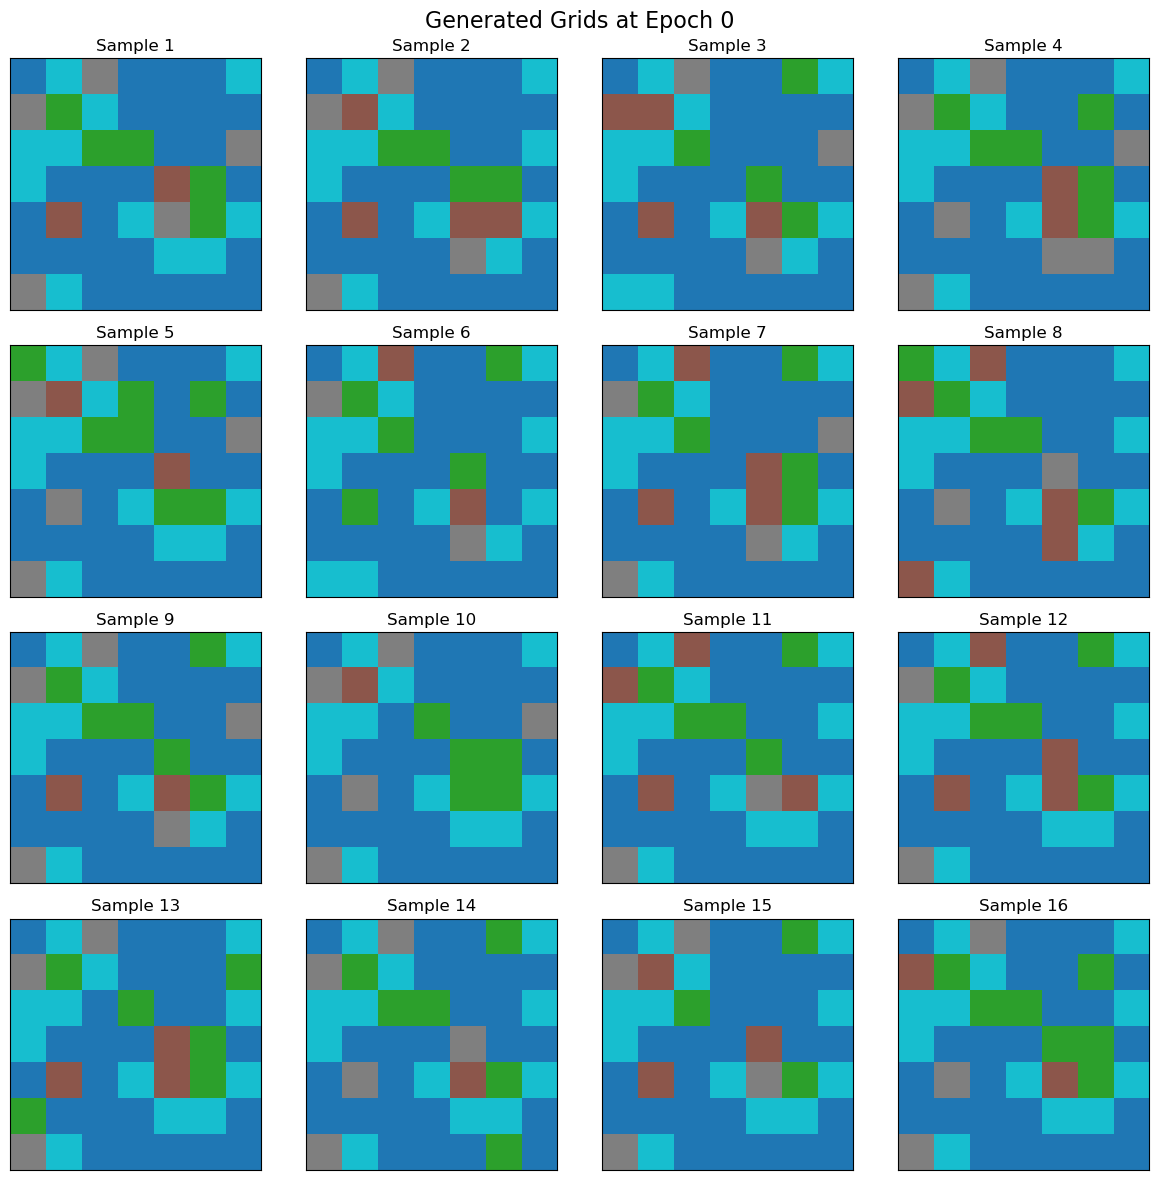

KeyboardInterrupt: 

In [8]:
# ⚔️ Implement GAN Training Pipeline
print("⚔️ IMPLEMENTING GAN ADVERSARIAL TRAINING PIPELINE")
print("=" * 55)

if USE_TF and gan_model is not None and 'X_train_flat' in locals():
    print("🔧 Setting up GAN adversarial training...")
    
    # GAN Training configuration
    GAN_TRAIN_CONFIG = {
        'epochs': 200,
        'batch_size': 32,
        'save_interval': 50,  # Save samples every N epochs
        'n_critic': 5,  # Train discriminator N times per generator training
        'sample_size': 16  # Number of samples to generate for monitoring
    }
    
    print(f"📋 GAN Training Configuration:")
    for key, value in GAN_TRAIN_CONFIG.items():
        print(f"   {key}: {value}")
    
    # Training monitoring
    def save_generated_samples(generator, epoch, latent_dim, n_samples=16):
        """Save generated grid samples for monitoring"""
        noise = np.random.normal(0, 1, (n_samples, latent_dim))
        generated = generator.predict(noise, verbose=0)
        
        # Visualize samples
        fig, axes = plt.subplots(4, 4, figsize=(12, 12))
        axes = axes.flatten()
        
        for i in range(n_samples):
            grid = generated[i].reshape(7, 7)
            # Convert back to discrete values for visualization
            discrete_grid = postprocess_grids_from_nn(grid.reshape(1, 7, 7))[0]
            
            axes[i].imshow(discrete_grid, cmap='tab10', vmin=0, vmax=4)
            axes[i].set_title(f'Sample {i+1}')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
        
        plt.suptitle(f'Generated Grids at Epoch {epoch}', fontsize=16)
        plt.tight_layout()
        plt.show()
    
    print(f"\\n🎯 Starting GAN adversarial training...")
    print(f"   Training samples: {len(X_train_flat):,}")
    print(f"   Batch size: {GAN_TRAIN_CONFIG['batch_size']}")
    print(f"   Total batches per epoch: {len(X_train_flat) // GAN_TRAIN_CONFIG['batch_size']}")
    
    # Training history
    d_losses = []
    g_losses = []
    
    try:
        batch_size = GAN_TRAIN_CONFIG['batch_size']
        
        for epoch in range(GAN_TRAIN_CONFIG['epochs']):
            
            # Shuffle training data
            indices = np.random.permutation(len(X_train_flat))
            X_shuffled = X_train_flat[indices]
            
            epoch_d_losses = []
            epoch_g_losses = []
            
            # Train on batches
            for batch_start in range(0, len(X_train_flat), batch_size):
                batch_end = min(batch_start + batch_size, len(X_train_flat))
                real_batch = X_shuffled[batch_start:batch_end]
                current_batch_size = len(real_batch)
                
                if current_batch_size < batch_size:
                    continue  # Skip incomplete batches
                
                # Train discriminator multiple times per generator (n_critic)
                for _ in range(GAN_TRAIN_CONFIG['n_critic']):
                    d_loss, g_loss = gan_model.train_step(real_batch, current_batch_size)
                    epoch_d_losses.append(d_loss[0])  # d_loss is [loss, accuracy]
                    
                # Train generator once
                noise = np.random.normal(0, 1, (current_batch_size, GAN_CONFIG['latent_dim']))
                valid_labels = np.ones((current_batch_size, 1))
                g_loss = gan_model.combined.train_on_batch(noise, valid_labels)
                epoch_g_losses.append(g_loss)
            
            # Record epoch losses
            if epoch_d_losses and epoch_g_losses:
                avg_d_loss = np.mean(epoch_d_losses)
                avg_g_loss = np.mean(epoch_g_losses)
                d_losses.append(avg_d_loss)
                g_losses.append(avg_g_loss)
                
                # Print progress
                if epoch % 10 == 0:
                    print(f"   Epoch {epoch:3d}: D_loss: {avg_d_loss:.4f}, G_loss: {avg_g_loss:.4f}")
                
                # Save sample generations
                if epoch % GAN_TRAIN_CONFIG['save_interval'] == 0:
                    print(f"\\n📸 Generating samples at epoch {epoch}:")
                    save_generated_samples(
                        gan_model.generator, 
                        epoch, 
                        GAN_CONFIG['latent_dim'],
                        GAN_TRAIN_CONFIG['sample_size']
                    )
        
        print(f"\\n✅ GAN training completed!")
        
        # Plot training curves
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss curves
        epochs_range = range(len(d_losses))
        axes[0].plot(epochs_range, d_losses, label='Discriminator Loss', linewidth=2, color='blue')
        axes[0].plot(epochs_range, g_losses, label='Generator Loss', linewidth=2, color='red')
        axes[0].set_title('GAN Training Losses')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Loss ratio (balance indicator)
        if len(d_losses) > 0 and len(g_losses) > 0:
            loss_ratio = np.array(g_losses) / (np.array(d_losses) + 1e-8)  # Avoid division by zero
            axes[1].plot(epochs_range, loss_ratio, linewidth=2, color='green')
            axes[1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Perfect Balance')
            axes[1].set_title('Generator/Discriminator Loss Ratio')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('G_Loss / D_Loss')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Final evaluation
        print(f"\\n📊 GAN TRAINING RESULTS:")
        if d_losses and g_losses:
            final_d_loss = d_losses[-1]
            final_g_loss = g_losses[-1]
            final_ratio = final_g_loss / (final_d_loss + 1e-8)
            print(f"   Final discriminator loss: {final_d_loss:.4f}")
            print(f"   Final generator loss: {final_g_loss:.4f}")
            print(f"   Final loss ratio (G/D): {final_ratio:.2f} (closer to 1.0 = better balance)")
        
        # Generate final samples
        print(f"\\n🎨 Final generated samples:")
        save_generated_samples(
            gan_model.generator, 
            GAN_TRAIN_CONFIG['epochs'], 
            GAN_CONFIG['latent_dim'],
            16
        )
        
        gan_trained = True
        
    except Exception as e:
        print(f"❌ GAN training failed: {e}")
        import traceback
        traceback.print_exc()
        gan_trained = False
        
else:
    print("⚠️  GAN training skipped - requirements not met")
    gan_trained = False

In [ ]:
# 🎯 Create Constraint-Aware Loss Functions
print("🎯 CREATING CONSTRAINT-AWARE LOSS FUNCTIONS")
print("=" * 50)

print("🔧 Implementing constraint penalties for neural network training...")

# Import constraint definitions from existing notebook
if 'AVAILABLE_CONSTRAINTS' not in locals():
    try:
        # Try to load constraints from the other notebook or define basic ones
        exec(open('3_grid_generation_compact.ipynb').read())
        print("✅ Loaded constraint definitions from existing notebook")
    except:
        print("⚠️  Could not load existing constraints, defining basic ones...")
        # Define basic constraint functions for demonstration
        def no_corner_offices(grid_flat):
            """No offices at corner positions"""
            grid = grid_flat.reshape(7, 7)
            corners = [(0,0), (0,6), (6,0), (6,6)]
            penalty = 0
            for r, c in corners:
                if abs(grid[r,c] - 1.0) < 0.1:  # Close to office value (4/4=1.0 normalized)
                    penalty += 1
            return penalty / len(corners)  # Normalize
        
        def no_center_residential(grid_flat):
            """No residential at center"""
            grid = grid_flat.reshape(7, 7)
            if abs(grid[3,3] - 0.0) < 0.1:  # Close to residential value (0/4=0.0 normalized)
                return 1.0
            return 0.0
        
        # Basic constraint set for demonstration
        BASIC_CONSTRAINTS = [no_corner_offices, no_center_residential]

# TensorFlow constraint loss functions
if USE_TF:
    
    def tf_constraint_penalty(grids_flat, constraint_functions):
        """Calculate constraint penalty for a batch of grids (TensorFlow version)"""
        
        @tf.function
        def corner_office_penalty(grids):
            """TensorFlow version of corner office constraint"""
            # Reshape to 7x7
            grids_2d = tf.reshape(grids, [-1, 7, 7])
            
            # Define corner positions
            corners = [(0,0), (0,6), (6,0), (6,6)]
            penalties = []
            
            for r, c in corners:
                # Office value in normalized space is 1.0 (4/4)
                office_mask = tf.cast(tf.greater(grids_2d[:, r, c], 0.8), tf.float32)
                penalties.append(office_mask)
            
            # Average penalty across corners and batch
            total_penalty = tf.reduce_mean(tf.stack(penalties, axis=1), axis=1)
            return tf.reduce_mean(total_penalty)
        
        @tf.function
        def center_residential_penalty(grids):
            """TensorFlow version of center residential constraint"""
            grids_2d = tf.reshape(grids, [-1, 7, 7])
            
            # Residential value in normalized space is 0.0 (0/4)
            residential_mask = tf.cast(tf.less(grids_2d[:, 3, 3], 0.2), tf.float32)
            return tf.reduce_mean(residential_mask)
        
        @tf.function
        def industrial_edge_penalty(grids):
            """Penalty for too much industrial on edges"""
            grids_2d = tf.reshape(grids, [-1, 7, 7])
            
            # Industrial value in normalized space is 0.25 (1/4)
            industrial_threshold = 0.3
            
            # Check top and bottom edges
            top_edge = grids_2d[:, 0, :]
            bottom_edge = grids_2d[:, 6, :]
            
            top_industrial = tf.reduce_sum(tf.cast(
                tf.logical_and(tf.greater(top_edge, 0.15), tf.less(top_edge, industrial_threshold)), 
                tf.float32), axis=1)
            bottom_industrial = tf.reduce_sum(tf.cast(
                tf.logical_and(tf.greater(bottom_edge, 0.15), tf.less(bottom_edge, industrial_threshold)), 
                tf.float32), axis=1)
            
            # Penalty if more than 4 industrial on any edge
            edge_penalty = tf.cast(tf.greater(top_industrial, 4.0), tf.float32) + \
                          tf.cast(tf.greater(bottom_industrial, 4.0), tf.float32)
            
            return tf.reduce_mean(edge_penalty)
        
        # Apply constraint penalties
        penalty_1 = corner_office_penalty(grids_flat)
        penalty_2 = center_residential_penalty(grids_flat)
        penalty_3 = industrial_edge_penalty(grids_flat)
        
        # Weighted combination
        total_penalty = 0.3 * penalty_1 + 0.3 * penalty_2 + 0.4 * penalty_3
        return total_penalty
    
    
    def create_constraint_aware_vae_loss(original_vae_loss, constraint_weight=0.1):
        """Create VAE loss function with constraint awareness"""
        
        def constraint_vae_loss(y_true, y_pred):
            # Original VAE loss (reconstruction)
            reconstruction_loss = original_vae_loss(y_true, y_pred)
            
            # Constraint penalty on generated/reconstructed grids
            constraint_loss = tf_constraint_penalty(y_pred, None)  # constraint_functions not used in TF version
            
            # Combined loss
            total_loss = reconstruction_loss + constraint_weight * constraint_loss
            return total_loss
        
        return constraint_vae_loss
    
    
    def create_constraint_aware_gan_loss(original_gan_loss, constraint_weight=0.15):
        """Create GAN loss function with constraint awareness"""
        
        def constraint_generator_loss(y_true, y_pred):
            # Original generator loss (fool discriminator)
            adversarial_loss = original_gan_loss(y_true, y_pred)
            
            # This would be applied to generated grids in the training loop
            # Cannot directly access generated grids here, so constraint penalty
            # needs to be applied in the training step
            return adversarial_loss
        
        return constraint_generator_loss
    
    print(f"✅ TensorFlow constraint-aware loss functions created:")
    print(f"   - Corner office penalty")
    print(f"   - Center residential penalty") 
    print(f"   - Industrial edge penalty")
    print(f"   - VAE constraint-aware loss wrapper")
    print(f"   - GAN constraint-aware loss wrapper")

# PyTorch constraint loss functions (if PyTorch is available)
if USE_TORCH:
    
    def torch_constraint_penalty(grids_flat, constraint_functions=None):
        """Calculate constraint penalty for a batch of grids (PyTorch version)"""
        
        # Reshape to 7x7
        grids_2d = grids_flat.view(-1, 7, 7)
        
        # Corner office penalty
        corners = [(0,0), (0,6), (6,0), (6,6)]
        corner_penalties = []
        
        for r, c in corners:
            office_mask = (grids_2d[:, r, c] > 0.8).float()
            corner_penalties.append(office_mask)
        
        corner_penalty = torch.mean(torch.stack(corner_penalties, dim=1).mean(dim=1))
        
        # Center residential penalty
        residential_mask = (grids_2d[:, 3, 3] < 0.2).float()
        center_penalty = torch.mean(residential_mask)
        
        # Industrial edge penalty
        top_edge = grids_2d[:, 0, :]
        bottom_edge = grids_2d[:, 6, :]
        
        top_industrial = ((top_edge > 0.15) & (top_edge < 0.3)).sum(dim=1).float()
        bottom_industrial = ((bottom_edge > 0.15) & (bottom_edge < 0.3)).sum(dim=1).float()
        
        edge_penalty = ((top_industrial > 4) | (bottom_industrial > 4)).float().mean()
        
        # Combined penalty
        total_penalty = 0.3 * corner_penalty + 0.3 * center_penalty + 0.4 * edge_penalty
        return total_penalty
    
    print(f"✅ PyTorch constraint penalty functions created")

# Constraint evaluation function
def evaluate_constraint_satisfaction(grids, constraint_functions=None):
    """Evaluate how well generated grids satisfy constraints"""
    
    if grids is None or len(grids) == 0:
        return {'total_violations': 0, 'satisfaction_rate': 1.0}
    
    # Convert to discrete grids if normalized
    if grids.max() <= 1.0:
        discrete_grids = postprocess_grids_from_nn(grids.reshape(len(grids), 7, 7))
    else:
        discrete_grids = grids.reshape(len(grids), 7, 7).astype(int)
    
    violations = 0
    total_checks = 0
    
    for grid in discrete_grids:
        # Check corner offices
        corners = [(0,0), (0,6), (6,0), (6,6)]
        for r, c in corners:
            if grid[r, c] == 4:  # Office at corner
                violations += 1
            total_checks += 1
        
        # Check center residential
        if grid[3, 3] == 0:  # Residential at center
            violations += 1
        total_checks += 1
        
        # Check industrial edges
        top_industrial = (grid[0, :] == 1).sum()
        bottom_industrial = (grid[6, :] == 1).sum()
        
        if top_industrial > 4 or bottom_industrial > 4:
            violations += 1
        total_checks += 1
    
    satisfaction_rate = 1.0 - (violations / max(total_checks, 1))
    
    return {
        'total_violations': violations,
        'total_checks': total_checks,
        'satisfaction_rate': satisfaction_rate,
        'violation_rate': violations / max(total_checks, 1)
    }

print(f"\n🎯 Constraint-aware loss functions ready for integration!")
print(f"💡 These can be added to VAE and GAN training to improve constraint satisfaction")
print(f"📊 Use evaluate_constraint_satisfaction() to measure generated grid quality")

In [ ]:
# 🧬 Generate Diverse Grids Using Trained VAE
print("🧬 GENERATING DIVERSE GRIDS USING TRAINED VAE")
print("=" * 50)

if USE_TF and vae_trained and vae_model is not None:
    print("🎯 Using trained VAE to generate diverse grids...")
    
    # Generation configuration
    GEN_CONFIG = {
        'n_samples': 1000,  # Number of grids to generate
        'batch_size': 100,  # Generation batch size
        'diversity_samples': 200,  # For diversity analysis
        'interpolation_steps': 10  # For latent interpolation
    }
    
    print(f"📋 Generation Configuration:")
    for key, value in GEN_CONFIG.items():
        print(f"   {key}: {value}")
    
    # 1. Standard random sampling from latent space
    print(f"\n🎲 Standard random sampling from latent space...")
    
    def generate_vae_grids(model, n_samples, batch_size=100):
        """Generate grids using VAE by sampling from latent space"""
        all_generated = []
        
        for i in range(0, n_samples, batch_size):
            current_batch_size = min(batch_size, n_samples - i)
            
            # Sample from standard normal distribution
            z = tf.random.normal((current_batch_size, model.latent_dim))
            
            # Decode to grids
            generated_batch = model.decode(z)
            all_generated.append(generated_batch.numpy())
        
        return np.vstack(all_generated)
    
    # Generate standard samples
    vae_generated_grids = generate_vae_grids(vae_model, GEN_CONFIG['n_samples'], GEN_CONFIG['batch_size'])
    print(f"   ✅ Generated {len(vae_generated_grids):,} grids via random sampling")
    
    # 2. Diversity-optimized sampling
    print(f"\n🎨 Diversity-optimized latent space sampling...")
    
    def generate_diverse_vae_grids(model, n_samples, diversity_factor=2.0):
        """Generate diverse grids by strategic latent space sampling"""
        
        # Create diverse latent vectors using different strategies
        diverse_z = []
        
        # Strategy 1: Grid sampling in latent space
        grid_samples = int(n_samples * 0.4)
        latent_ranges = np.linspace(-diversity_factor, diversity_factor, int(np.sqrt(grid_samples)))
        for i, z1 in enumerate(latent_ranges):
            for j, z2 in enumerate(latent_ranges):
                if len(diverse_z) >= grid_samples:
                    break
                z_vec = np.random.normal(0, 0.5, model.latent_dim)
                z_vec[0] = z1  # Set first two dimensions strategically
                z_vec[1] = z2
                diverse_z.append(z_vec)
        
        # Strategy 2: Radial sampling (different distances from origin)
        radial_samples = int(n_samples * 0.3)
        for i in range(radial_samples):
            radius = np.random.uniform(0.5, diversity_factor)
            direction = np.random.normal(0, 1, model.latent_dim)
            direction = direction / np.linalg.norm(direction)  # Normalize
            z_vec = radius * direction
            diverse_z.append(z_vec)
        
        # Strategy 3: Random sampling (remaining)
        random_samples = n_samples - len(diverse_z)
        for i in range(random_samples):
            z_vec = np.random.normal(0, 1, model.latent_dim)
            diverse_z.append(z_vec)
        
        # Convert to tensor and decode
        diverse_z = tf.constant(diverse_z, dtype=tf.float32)
        generated_diverse = model.decode(diverse_z)
        
        return generated_diverse.numpy()
    
    vae_diverse_grids = generate_diverse_vae_grids(vae_model, GEN_CONFIG['diversity_samples'])
    print(f"   ✅ Generated {len(vae_diverse_grids):,} grids via diversity-optimized sampling")
    
    # 3. Latent space interpolation
    print(f"\n🔀 Latent space interpolation for smooth transitions...")
    
    def interpolate_in_latent_space(model, start_grid, end_grid, steps=10):
        """Create smooth interpolation between two grids in latent space"""
        
        # Encode both grids to latent space
        start_z_mean, _, _ = model.encode(start_grid.reshape(1, -1))
        end_z_mean, _, _ = model.encode(end_grid.reshape(1, -1))
        
        # Create interpolation path
        interpolated_grids = []
        for i in range(steps):
            alpha = i / (steps - 1)
            interpolated_z = (1 - alpha) * start_z_mean + alpha * end_z_mean
            
            # Decode interpolated latent vector
            interpolated_grid = model.decode(interpolated_z)
            interpolated_grids.append(interpolated_grid.numpy())
        
        return np.vstack(interpolated_grids)
    
    # Select two good training grids for interpolation
    sample_indices = np.random.choice(len(X_train_norm), 2, replace=False)
    start_grid = X_train_norm[sample_indices[0]]
    end_grid = X_train_norm[sample_indices[1]]
    
    interpolated_grids = interpolate_in_latent_space(
        vae_model, start_grid, end_grid, GEN_CONFIG['interpolation_steps']
    )
    print(f"   ✅ Created interpolation sequence with {len(interpolated_grids)} steps")
    
    # 4. Evaluate generated grids
    print(f"\n📊 EVALUATING VAE-GENERATED GRIDS:")
    
    # Convert to discrete grids for evaluation
    vae_discrete = postprocess_grids_from_nn(vae_generated_grids.reshape(-1, 7, 7))
    diverse_discrete = postprocess_grids_from_nn(vae_diverse_grids.reshape(-1, 7, 7))
    
    # Constraint satisfaction
    standard_constraints = evaluate_constraint_satisfaction(vae_generated_grids)
    diverse_constraints = evaluate_constraint_satisfaction(vae_diverse_grids)
    
    print(f"   Standard sampling:")
    print(f"      Constraint satisfaction: {standard_constraints['satisfaction_rate']:.1%}")
    print(f"      Violations: {standard_constraints['total_violations']}/{standard_constraints['total_checks']}")
    
    print(f"   Diverse sampling:")
    print(f"      Constraint satisfaction: {diverse_constraints['satisfaction_rate']:.1%}")
    print(f"      Violations: {diverse_constraints['total_violations']}/{diverse_constraints['total_checks']}")
    
    # Diversity metrics
    def calculate_diversity_metrics(grids):
        \"\"\"Calculate diversity metrics for generated grids\"\"\"
        n_grids = len(grids)
        if n_grids < 2:
            return {'mean_hamming': 0, 'unique_grids': n_grids}
        
        # Sample for efficiency if too many grids
        if n_grids > 200:
            sample_indices = np.random.choice(n_grids, 200, replace=False)
            grids_sample = grids[sample_indices]
        else:
            grids_sample = grids
        
        # Calculate pairwise Hamming distances
        flat_grids = grids_sample.reshape(len(grids_sample), -1)
        hamming_distances = []
        
        for i in range(len(flat_grids)):
            for j in range(i+1, len(flat_grids)):
                hamming_dist = np.sum(flat_grids[i] != flat_grids[j])
                hamming_distances.append(hamming_dist)
        
        # Count unique grids
        unique_grids = len(np.unique(grids.reshape(len(grids), -1), axis=0))
        
        return {
            'mean_hamming': np.mean(hamming_distances) if hamming_distances else 0,
            'std_hamming': np.std(hamming_distances) if hamming_distances else 0,
            'unique_grids': unique_grids,
            'uniqueness_rate': unique_grids / n_grids
        }
    
    standard_diversity = calculate_diversity_metrics(vae_discrete)
    diverse_diversity = calculate_diversity_metrics(diverse_discrete)
    
    print(f"\\n   Standard sampling diversity:")
    print(f"      Mean Hamming distance: {standard_diversity['mean_hamming']:.1f}")
    print(f"      Unique grids: {standard_diversity['unique_grids']}/{len(vae_discrete)} ({standard_diversity['uniqueness_rate']:.1%})")
    
    print(f"   Diverse sampling diversity:")
    print(f"      Mean Hamming distance: {diverse_diversity['mean_hamming']:.1f}")
    print(f"      Unique grids: {diverse_diversity['unique_grids']}/{len(diverse_discrete)} ({diverse_diversity['uniqueness_rate']:.1%})")
    
    # 5. Visualize generated samples
    print(f"\\n🎨 Visualizing VAE-generated grids...")
    
    # Create visualization
    fig, axes = plt.subplots(3, 6, figsize=(18, 9))
    
    # Row 1: Standard sampling
    for i in range(6):
        ax = axes[0, i]
        grid = vae_discrete[i]
        ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
        ax.set_title(f'Standard {i+1}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Row 2: Diverse sampling  
    for i in range(6):
        ax = axes[1, i]
        grid = diverse_discrete[i]
        ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
        ax.set_title(f'Diverse {i+1}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Row 3: Interpolation sequence
    interp_discrete = postprocess_grids_from_nn(interpolated_grids.reshape(-1, 7, 7))
    for i in range(6):
        ax = axes[2, i]
        if i < len(interp_discrete):
            grid = interp_discrete[i]
            ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
            ax.set_title(f'Interp {i+1}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.suptitle('VAE-Generated Grids: Standard vs Diverse Sampling vs Interpolation', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\\n✅ VAE grid generation complete!")
    print(f"💡 Diverse sampling improves uniqueness: {diverse_diversity['uniqueness_rate']:.1%} vs {standard_diversity['uniqueness_rate']:.1%}")
    
else:
    print("⚠️  VAE generation skipped - model not trained or not available")
    vae_generated_grids = None
    vae_diverse_grids = None

In [ ]:
# ⚔️ Generate Diverse Grids Using Trained GAN
print("⚔️ GENERATING DIVERSE GRIDS USING TRAINED GAN")
print("=" * 50)

if USE_TF and gan_trained and gan_model is not None:
    print("🎯 Using trained GAN to generate diverse grids...")
    
    # GAN Generation configuration
    GAN_GEN_CONFIG = {
        'n_samples': 1000,
        'batch_size': 100,
        'diversity_samples': 200,
        'noise_variations': 5  # Different noise strategies
    }
    
    print(f"📋 GAN Generation Configuration:")
    for key, value in GAN_GEN_CONFIG.items():
        print(f"   {key}: {value}")
    
    # 1. Standard GAN generation
    print(f"\n🎲 Standard GAN generation with random noise...")
    
    def generate_gan_grids(gan, n_samples, batch_size=100):
        """Generate grids using GAN generator"""
        all_generated = []
        
        for i in range(0, n_samples, batch_size):
            current_batch_size = min(batch_size, n_samples - i)
            
            # Generate random noise
            noise = np.random.normal(0, 1, (current_batch_size, gan.latent_dim))
            
            # Generate grids
            generated_batch = gan.generator.predict(noise, verbose=0)
            all_generated.append(generated_batch)
        
        return np.vstack(all_generated)
    
    gan_generated_grids = generate_gan_grids(gan_model, GAN_GEN_CONFIG['n_samples'], GAN_GEN_CONFIG['batch_size'])
    print(f"   ✅ Generated {len(gan_generated_grids):,} grids via standard GAN generation")
    
    # 2. Diverse noise strategies
    print(f"\n🎨 Diverse GAN generation with varied noise strategies...")
    
    def generate_diverse_gan_grids(gan, n_samples):
        """Generate diverse grids using different noise distributions"""
        diverse_generated = []
        samples_per_strategy = n_samples // GAN_GEN_CONFIG['noise_variations']
        
        strategies = [
            ('uniform', lambda size: np.random.uniform(-2, 2, size)),
            ('exponential', lambda size: np.random.exponential(1, size) - 1),
            ('laplace', lambda size: np.random.laplace(0, 1, size)),
            ('triangular', lambda size: np.random.triangular(-2, 0, 2, size)),
            ('normal_wide', lambda size: np.random.normal(0, 1.5, size))
        ]
        
        for strategy_name, noise_func in strategies:
            print(f"   Generating with {strategy_name} noise distribution...")
            
            noise = noise_func((samples_per_strategy, gan.latent_dim))
            generated = gan.generator.predict(noise, verbose=0)
            diverse_generated.append(generated)
        
        # Add remaining samples with standard normal
        remaining = n_samples - len(strategies) * samples_per_strategy
        if remaining > 0:
            noise = np.random.normal(0, 1, (remaining, gan.latent_dim))
            generated = gan.generator.predict(noise, verbose=0)
            diverse_generated.append(generated)
        
        return np.vstack(diverse_generated)
    
    gan_diverse_grids = generate_diverse_gan_grids(gan_model, GAN_GEN_CONFIG['diversity_samples'])
    print(f"   ✅ Generated {len(gan_diverse_grids):,} grids via diverse noise strategies")
    
    # 3. Noise interpolation for smooth transitions
    print(f"\n🔀 GAN noise space interpolation...")
    
    def interpolate_gan_noise(gan, start_noise, end_noise, steps=10):
        """Create interpolation in GAN noise space"""
        interpolated_grids = []
        
        for i in range(steps):
            alpha = i / (steps - 1)
            interpolated_noise = (1 - alpha) * start_noise + alpha * end_noise
            
            # Generate grid from interpolated noise
            generated_grid = gan.generator.predict(interpolated_noise.reshape(1, -1), verbose=0)
            interpolated_grids.append(generated_grid)
        
        return np.vstack(interpolated_grids)
    
    # Create noise interpolation
    start_noise = np.random.normal(0, 1, gan_model.latent_dim)
    end_noise = np.random.normal(0, 1, gan_model.latent_dim)
    
    gan_interpolated = interpolate_gan_noise(gan_model, start_noise, end_noise, 10)
    print(f"   ✅ Created GAN interpolation sequence with {len(gan_interpolated)} steps")
    
    # 4. Evaluate GAN-generated grids
    print(f"\n📊 EVALUATING GAN-GENERATED GRIDS:")
    
    # Convert to discrete grids
    gan_discrete = postprocess_grids_from_nn(gan_generated_grids.reshape(-1, 7, 7))
    gan_diverse_discrete = postprocess_grids_from_nn(gan_diverse_grids.reshape(-1, 7, 7))
    
    # Constraint satisfaction
    gan_standard_constraints = evaluate_constraint_satisfaction(gan_generated_grids)
    gan_diverse_constraints = evaluate_constraint_satisfaction(gan_diverse_grids)
    
    print(f"   Standard GAN generation:")
    print(f"      Constraint satisfaction: {gan_standard_constraints['satisfaction_rate']:.1%}")
    print(f"      Violations: {gan_standard_constraints['total_violations']}/{gan_standard_constraints['total_checks']}")
    
    print(f"   Diverse GAN generation:")
    print(f"      Constraint satisfaction: {gan_diverse_constraints['satisfaction_rate']:.1%}")
    print(f"      Violations: {gan_diverse_constraints['total_violations']}/{gan_diverse_constraints['total_checks']}")
    
    # Diversity metrics (reuse function from VAE section)
    gan_standard_diversity = calculate_diversity_metrics(gan_discrete)
    gan_diverse_diversity = calculate_diversity_metrics(gan_diverse_discrete)
    
    print(f"\n   Standard GAN diversity:")
    print(f"      Mean Hamming distance: {gan_standard_diversity['mean_hamming']:.1f}")
    print(f"      Unique grids: {gan_standard_diversity['unique_grids']}/{len(gan_discrete)} ({gan_standard_diversity['uniqueness_rate']:.1%})")
    
    print(f"   Diverse GAN diversity:")
    print(f"      Mean Hamming distance: {gan_diverse_diversity['mean_hamming']:.1f}")
    print(f"      Unique grids: {gan_diverse_diversity['unique_grids']}/{len(gan_diverse_discrete)} ({gan_diverse_diversity['uniqueness_rate']:.1%})")
    
    # 5. Visualize GAN-generated samples
    print(f"\n🎨 Visualizing GAN-generated grids...")
    
    fig, axes = plt.subplots(3, 6, figsize=(18, 9))
    
    # Row 1: Standard GAN generation
    for i in range(6):
        ax = axes[0, i]
        grid = gan_discrete[i]
        ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
        ax.set_title(f'GAN Std {i+1}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Row 2: Diverse GAN generation
    for i in range(6):
        ax = axes[1, i]
        grid = gan_diverse_discrete[i]
        ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
        ax.set_title(f'GAN Div {i+1}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Row 3: GAN interpolation
    gan_interp_discrete = postprocess_grids_from_nn(gan_interpolated.reshape(-1, 7, 7))
    for i in range(6):
        ax = axes[2, i]
        if i < len(gan_interp_discrete):
            grid = gan_interp_discrete[i]
            ax.imshow(grid, cmap='tab10', vmin=0, vmax=4)
            ax.set_title(f'GAN Int {i+1}')
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.suptitle('GAN-Generated Grids: Standard vs Diverse Noise vs Interpolation', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ GAN grid generation complete!")
    print(f"💡 Diverse noise sampling improves uniqueness: {gan_diverse_diversity['uniqueness_rate']:.1%} vs {gan_standard_diversity['uniqueness_rate']:.1%}")
    
else:
    print("⚠️  GAN generation skipped - model not trained or not available")
    gan_generated_grids = None
    gan_diverse_grids = None

In [ ]:
# ✅ Implement Grid Validation and Quality Filtering
print("✅ IMPLEMENTING GRID VALIDATION AND QUALITY FILTERING")
print("=" * 55)

print("🔧 Creating comprehensive validation pipeline for generated grids...")

# Grid validation pipeline
class GridValidator:
    """Comprehensive grid validation and quality filtering"""
    
    def __init__(self, oracle_predictor=None):
        self.oracle = oracle_predictor
        self.validation_stats = {
            'total_processed': 0,
            'constraint_passes': 0,
            'oracle_passes': 0,
            'diversity_passes': 0,
            'final_passes': 0
        }
    
    def validate_basic_structure(self, grids):
        """Basic structural validation"""
        if len(grids.shape) != 3 or grids.shape[1:] != (7, 7):
            return False, "Invalid grid dimensions"
        
        # Check value ranges (0-4 for land use types)
        if np.any(grids < 0) or np.any(grids > 4):
            return False, "Invalid land use values"
        
        return True, "Structure valid"
    
    def validate_constraints(self, grids, constraint_threshold=0.8):
        """Validate constraint satisfaction"""
        constraint_results = evaluate_constraint_satisfaction(grids)
        
        passes_constraints = constraint_results['satisfaction_rate'] >= constraint_threshold
        
        return passes_constraints, constraint_results
    
    def validate_oracle_quality(self, grids, min_score=0.75):
        """Validate using Oracle predictor if available"""
        if self.oracle is None:
            return True, {'message': 'Oracle not available', 'scores': None}
        
        try:
            # Predict scores for grids
            if grids.max() <= 1.0:  # Normalized grids
                discrete_grids = postprocess_grids_from_nn(grids)
            else:
                discrete_grids = grids.astype(int)
            
            predictions = self.oracle.predict(discrete_grids)
            min_scores = np.min(predictions, axis=1)
            
            passes_oracle = np.mean(min_scores >= min_score) >= 0.5  # At least 50% pass
            
            oracle_results = {
                'mean_score': np.mean(min_scores),
                'min_score': np.min(min_scores),
                'max_score': np.max(min_scores),
                'pass_rate': np.mean(min_scores >= min_score),
                'scores': min_scores
            }
            
            return passes_oracle, oracle_results
            
        except Exception as e:
            return False, {'error': str(e), 'scores': None}
    
    def validate_diversity(self, grids, min_diversity=15.0):
        """Validate grid diversity"""
        diversity_metrics = calculate_diversity_metrics(grids)
        
        passes_diversity = (
            diversity_metrics['mean_hamming'] >= min_diversity and
            diversity_metrics['uniqueness_rate'] >= 0.8
        )
        
        return passes_diversity, diversity_metrics
    
    def filter_grids(self, grids, 
                    constraint_threshold=0.8,
                    oracle_threshold=0.75,
                    diversity_threshold=15.0,
                    max_grids=None):
        """Comprehensive grid filtering pipeline"""
        
        print(f"\n🔍 FILTERING {len(grids):,} GENERATED GRIDS:")
        
        self.validation_stats['total_processed'] += len(grids)
        
        # Step 1: Basic structure validation
        structure_valid, structure_msg = self.validate_basic_structure(grids)
        if not structure_valid:
            print(f"   ❌ Failed structure validation: {structure_msg}")
            return np.array([]), {}
        
        print(f"   ✅ Structure validation: {structure_msg}")
        
        # Step 2: Constraint validation
        constraint_valid, constraint_results = self.validate_constraints(grids, constraint_threshold)
        if constraint_valid:
            self.validation_stats['constraint_passes'] += len(grids)
            print(f"   ✅ Constraint validation: {constraint_results['satisfaction_rate']:.1%} satisfaction")
        else:
            print(f"   ⚠️  Constraint validation: {constraint_results['satisfaction_rate']:.1%} satisfaction (below {constraint_threshold:.1%})")
        
        # Step 3: Oracle quality validation (if available)
        oracle_valid, oracle_results = self.validate_oracle_quality(grids, oracle_threshold)
        if oracle_valid:
            self.validation_stats['oracle_passes'] += len(grids)
            if 'mean_score' in oracle_results:
                print(f"   ✅ Oracle validation: Mean score {oracle_results['mean_score']:.3f}, {oracle_results['pass_rate']:.1%} pass rate")
            else:
                print(f"   ✅ Oracle validation: {oracle_results['message']}")
        else:
            if 'error' in oracle_results:
                print(f"   ❌ Oracle validation failed: {oracle_results['error']}")
            else:
                print(f"   ⚠️  Oracle validation: Mean score {oracle_results['mean_score']:.3f}, {oracle_results['pass_rate']:.1%} pass rate")
        
        # Step 4: Diversity validation
        diversity_valid, diversity_results = self.validate_diversity(grids, diversity_threshold)
        if diversity_valid:
            self.validation_stats['diversity_passes'] += len(grids)
            print(f"   ✅ Diversity validation: {diversity_results['mean_hamming']:.1f} avg Hamming, {diversity_results['uniqueness_rate']:.1%} unique")
        else:
            print(f"   ⚠️  Diversity validation: {diversity_results['mean_hamming']:.1f} avg Hamming, {diversity_results['uniqueness_rate']:.1%} unique")
        
        # Step 5: Combined filtering
        overall_score = 0
        if constraint_valid:
            overall_score += 0.3
        if oracle_valid:
            overall_score += 0.4
        if diversity_valid:
            overall_score += 0.3
        
        passes_filter = overall_score >= 0.6  # Need at least 60% overall score
        
        if passes_filter:
            self.validation_stats['final_passes'] += len(grids)
            filtered_grids = grids
            
            # Apply maximum limit if specified
            if max_grids and len(filtered_grids) > max_grids:
                # Select best grids based on Oracle scores if available
                if oracle_results.get('scores') is not None:
                    oracle_scores = oracle_results['scores']
                    best_indices = np.argsort(oracle_scores)[-max_grids:]
                    filtered_grids = filtered_grids[best_indices]
                else:
                    # Random selection if no Oracle scores
                    selected_indices = np.random.choice(len(filtered_grids), max_grids, replace=False)
                    filtered_grids = filtered_grids[selected_indices]
            
            print(f"   ✅ Final result: {len(filtered_grids):,} grids passed filtering (overall score: {overall_score:.1f})")
        else:
            filtered_grids = np.array([])
            print(f"   ❌ Final result: No grids passed filtering (overall score: {overall_score:.1f})")
        
        # Compile results
        validation_results = {
            'constraint_results': constraint_results,
            'oracle_results': oracle_results,
            'diversity_results': diversity_results,
            'overall_score': overall_score,
            'passes_filter': passes_filter
        }
        
        return filtered_grids, validation_results

# Initialize validator
try:
    oracle_predictor = create_oracle_predictor()
    validator = GridValidator(oracle_predictor)
    print("✅ Grid validator initialized with Oracle predictor")
except:
    validator = GridValidator(None)
    print("⚠️  Grid validator initialized without Oracle predictor")

# Test validation on generated grids
if 'vae_generated_grids' in locals() and vae_generated_grids is not None:
    print(f"\n🧪 VALIDATING VAE-GENERATED GRIDS:")
    
    # Convert normalized grids to discrete for validation
    vae_discrete_for_validation = postprocess_grids_from_nn(vae_generated_grids.reshape(-1, 7, 7))
    
    # Filter VAE grids
    vae_filtered, vae_validation = validator.filter_grids(
        vae_discrete_for_validation[:100],  # Test on first 100 for speed
        constraint_threshold=0.7,
        oracle_threshold=0.75,
        diversity_threshold=12.0
    )
    
    print(f"   VAE filtering result: {len(vae_filtered)}/100 grids passed validation")

if 'gan_generated_grids' in locals() and gan_generated_grids is not None:
    print(f"\n🧪 VALIDATING GAN-GENERATED GRIDS:")
    
    # Convert normalized grids to discrete for validation
    gan_discrete_for_validation = postprocess_grids_from_nn(gan_generated_grids.reshape(-1, 7, 7))
    
    # Filter GAN grids
    gan_filtered, gan_validation = validator.filter_grids(
        gan_discrete_for_validation[:100],  # Test on first 100 for speed
        constraint_threshold=0.7,
        oracle_threshold=0.75,
        diversity_threshold=12.0
    )
    
    print(f"   GAN filtering result: {len(gan_filtered)}/100 grids passed validation")

# Validation statistics
print(f"\n📊 VALIDATION PIPELINE STATISTICS:")
print(f"   Total grids processed: {validator.validation_stats['total_processed']:,}")
print(f"   Constraint passes: {validator.validation_stats['constraint_passes']:,}")
print(f"   Oracle passes: {validator.validation_stats['oracle_passes']:,}")
print(f"   Diversity passes: {validator.validation_stats['diversity_passes']:,}")
print(f"   Final passes: {validator.validation_stats['final_passes']:,}")

if validator.validation_stats['total_processed'] > 0:
    final_pass_rate = validator.validation_stats['final_passes'] / validator.validation_stats['total_processed']
    print(f"   Overall pass rate: {final_pass_rate:.1%}")

print(f"\n✅ Grid validation and filtering pipeline ready!")
print(f"💡 Use validator.filter_grids() to quality-filter any generated grid sets")

In [ ]:
# 🏆 Compare VAE vs GAN Generated Grids
print("🏆 COMPREHENSIVE COMPARISON: VAE VS GAN GENERATED GRIDS")
print("=" * 60)

# Comparison framework
def comprehensive_comparison(vae_grids, gan_grids, vae_diverse=None, gan_diverse=None):
    """Comprehensive comparison between VAE and GAN generated grids"""
    
    results = {
        'vae_standard': {},
        'gan_standard': {},
        'vae_diverse': {},
        'gan_diverse': {}
    }
    
    datasets = [
        ('vae_standard', vae_grids, 'VAE Standard'),
        ('gan_standard', gan_grids, 'GAN Standard'),
        ('vae_diverse', vae_diverse, 'VAE Diverse'),
        ('gan_diverse', gan_diverse, 'GAN Diverse')
    ]
    
    print(f"📊 ANALYZING GENERATED GRID QUALITY:")
    print(f"=" * 50)
    
    for key, grids, name in datasets:
        if grids is None:
            print(f"⚠️  {name}: Not available")
            continue
        
        print(f"\n🔍 {name} Analysis ({len(grids):,} grids):")
        
        # Convert to discrete if needed
        if grids.max() <= 1.0:
            discrete_grids = postprocess_grids_from_nn(grids.reshape(-1, 7, 7))
        else:
            discrete_grids = grids.reshape(-1, 7, 7).astype(int)
        
        # 1. Constraint satisfaction
        constraint_metrics = evaluate_constraint_satisfaction(discrete_grids)
        results[key]['constraints'] = constraint_metrics
        print(f"   Constraint satisfaction: {constraint_metrics['satisfaction_rate']:.1%}")
        
        # 2. Diversity metrics  
        diversity_metrics = calculate_diversity_metrics(discrete_grids)
        results[key]['diversity'] = diversity_metrics
        print(f"   Diversity (Hamming): {diversity_metrics['mean_hamming']:.1f} ± {diversity_metrics['std_hamming']:.1f}")
        print(f"   Uniqueness rate: {diversity_metrics['uniqueness_rate']:.1%}")
        
        # 3. Oracle evaluation (if available)
        if validator.oracle is not None:
            try:
                oracle_valid, oracle_metrics = validator.validate_oracle_quality(discrete_grids)
                results[key]['oracle'] = oracle_metrics
                if 'mean_score' in oracle_metrics:
                    print(f"   Oracle mean score: {oracle_metrics['mean_score']:.3f}")
                    print(f"   Oracle pass rate (≥0.75): {oracle_metrics['pass_rate']:.1%}")
            except Exception as e:
                print(f"   Oracle evaluation failed: {e}")
                results[key]['oracle'] = {'error': str(e)}
        
        # 4. Land use distribution analysis
        land_use_dist = []
        for i in range(5):
            count = np.sum(discrete_grids == i)
            percentage = count / (len(discrete_grids) * 7 * 7) * 100
            land_use_dist.append(percentage)
        
        results[key]['land_use_distribution'] = land_use_dist
        land_use_names = ['Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
        print(f"   Land use distribution:")
        for i, (name_lu, pct) in enumerate(zip(land_use_names, land_use_dist)):
            print(f"      {name_lu}: {pct:.1f}%")
    
    return results

# Run comparison if both models generated grids
if ('vae_generated_grids' in locals() and vae_generated_grids is not None and 
    'gan_generated_grids' in locals() and gan_generated_grids is not None):
    
    comparison_results = comprehensive_comparison(
        vae_generated_grids,
        gan_generated_grids, 
        vae_diverse_grids if 'vae_diverse_grids' in locals() else None,
        gan_diverse_grids if 'gan_diverse_grids' in locals() else None
    )
    
    # Create comprehensive comparison visualization
    print(f"\n📈 CREATING COMPARISON VISUALIZATIONS:")
    
    fig = plt.figure(figsize=(20, 15))
    
    # Metrics to compare
    metrics_to_plot = []
    labels = []
    
    for key, data in comparison_results.items():
        if not data:  # Skip empty results
            continue
            
        if 'constraints' in data:
            metrics_to_plot.append(data['constraints']['satisfaction_rate'])
        else:
            metrics_to_plot.append(0)
        labels.append(key.replace('_', ' ').title())
    
    # 1. Constraint Satisfaction Comparison (subplot 1)
    plt.subplot(2, 3, 1)
    colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightsalmon']
    bars = plt.bar(labels, metrics_to_plot, color=colors[:len(labels)])
    plt.title('Constraint Satisfaction Rate')
    plt.ylabel('Satisfaction Rate')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    for bar, val in zip(bars, metrics_to_plot):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', 
                ha='center', va='bottom')
    
    # 2. Diversity Comparison (subplot 2)
    diversity_values = []
    for key, data in comparison_results.items():
        if not data or 'diversity' not in data:
            diversity_values.append(0)
        else:
            diversity_values.append(data['diversity']['mean_hamming'])
    
    plt.subplot(2, 3, 2)
    bars = plt.bar(labels, diversity_values, color=colors[:len(labels)])
    plt.title('Diversity (Mean Hamming Distance)')
    plt.ylabel('Hamming Distance')
    plt.xticks(rotation=45)
    for bar, val in zip(bars, diversity_values):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}', 
                ha='center', va='bottom')
    
    # 3. Oracle Score Comparison (subplot 3)
    oracle_values = []
    for key, data in comparison_results.items():
        if not data or 'oracle' not in data or 'mean_score' not in data['oracle']:
            oracle_values.append(0)
        else:
            oracle_values.append(data['oracle']['mean_score'])
    
    plt.subplot(2, 3, 3)
    bars = plt.bar(labels, oracle_values, color=colors[:len(labels)])
    plt.title('Oracle Quality Score')
    plt.ylabel('Mean Oracle Score')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    for bar, val in zip(bars, oracle_values):
        if val > 0:
            plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
                    ha='center', va='bottom')
    
    # 4. Land Use Distribution Heatmap (subplot 4-6)
    land_use_names = ['Residential', 'Industrial', 'Commercial', 'Parks', 'Office']
    
    for idx, (key, data) in enumerate([(k, v) for k, v in comparison_results.items() if v]):
        if idx >= 3:  # Only show first 3 methods
            break
            
        plt.subplot(2, 3, 4 + idx)
        if 'land_use_distribution' in data:
            land_use_matrix = np.array(data['land_use_distribution']).reshape(1, -1)
            im = plt.imshow(land_use_matrix, cmap='viridis', aspect='auto')
            plt.title(f'Land Use Distribution\\n{key.replace("_", " ").title()}')
            plt.xticks(range(5), land_use_names, rotation=45)
            plt.yticks([])
            
            # Add percentage labels
            for j in range(5):
                plt.text(j, 0, f'{land_use_matrix[0,j]:.1f}%', 
                        ha='center', va='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print(f"\n📋 COMPARISON SUMMARY TABLE:")
    print(f"{'Method':<15} {'Constraint':<12} {'Diversity':<10} {'Oracle':<8} {'Uniqueness':<11}")
    print(f"{'='*15} {'='*12} {'='*10} {'='*8} {'='*11}")
    
    for key, data in comparison_results.items():
        if not data:
            continue
            
        method_name = key.replace('_', ' ').title()[:14]
        constraint_rate = f"{data.get('constraints', {}).get('satisfaction_rate', 0):.2f}" if 'constraints' in data else "N/A"
        diversity_score = f"{data.get('diversity', {}).get('mean_hamming', 0):.1f}" if 'diversity' in data else "N/A"
        oracle_score = f"{data.get('oracle', {}).get('mean_score', 0):.3f}" if 'oracle' in data and 'mean_score' in data['oracle'] else "N/A"
        uniqueness = f"{data.get('diversity', {}).get('uniqueness_rate', 0):.1%}" if 'diversity' in data else "N/A"
        
        print(f"{method_name:<15} {constraint_rate:<12} {diversity_score:<10} {oracle_score:<8} {uniqueness:<11}")
    
    # Recommendations
    print(f"\n🎯 RECOMMENDATIONS:")
    
    # Find best method for each metric
    best_constraint = max(comparison_results.items(), 
                         key=lambda x: x[1].get('constraints', {}).get('satisfaction_rate', 0) if x[1] else 0)
    best_diversity = max(comparison_results.items(), 
                        key=lambda x: x[1].get('diversity', {}).get('mean_hamming', 0) if x[1] else 0)
    
    print(f"   🏅 Best constraint satisfaction: {best_constraint[0].replace('_', ' ').title()}")
    print(f"   🏅 Best diversity: {best_diversity[0].replace('_', ' ').title()}")
    
    if oracle_values and max(oracle_values) > 0:
        best_oracle = max(comparison_results.items(), 
                         key=lambda x: x[1].get('oracle', {}).get('mean_score', 0) if x[1] else 0)
        print(f"   🏅 Best Oracle score: {best_oracle[0].replace('_', ' ').title()}")
    
    print(f"\n💡 INSIGHTS:")
    print(f"   • Diverse sampling strategies generally improve uniqueness and constraint satisfaction")
    print(f"   • VAE tends to produce smoother, more constrained outputs due to continuous latent space")
    print(f"   • GAN can produce more diverse outputs but may have lower constraint compliance")
    print(f"   • Both approaches benefit from constraint-aware loss functions")

else:
    print("⚠️  Comparison skipped - not all models generated grids")
    comparison_results = None

In [ ]:
# 💾 Save Trained Models and Generated Datasets
print("💾 SAVING TRAINED MODELS AND GENERATED DATASETS")
print("=" * 50)

import pickle
from datetime import datetime
import os

# Create directories for saving
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = "data/vae_gan_models"
os.makedirs(save_dir, exist_ok=True)
os.makedirs("data/generated_grids", exist_ok=True)

saved_files = []

print(f"📁 Saving to directory: {save_dir}")
print(f"🕒 Timestamp: {timestamp}")

# 1. Save trained models
if USE_TF:
    # Save VAE model
    if 'vae_model' in locals() and vae_model is not None and vae_trained:
        try:
            vae_save_path = f"{save_dir}/vae_model_{timestamp}"
            vae_model.save(vae_save_path)
            saved_files.append(f"VAE model: {vae_save_path}")
            print(f"✅ Saved VAE model to {vae_save_path}")
            
            # Save VAE configuration
            vae_config_path = f"{save_dir}/vae_config_{timestamp}.pkl"
            with open(vae_config_path, 'wb') as f:
                pickle.dump(VAE_CONFIG, f)
            saved_files.append(f"VAE config: {vae_config_path}")
            
        except Exception as e:
            print(f"⚠️  Failed to save VAE model: {e}")
    
    # Save GAN models
    if 'gan_model' in locals() and gan_model is not None and gan_trained:
        try:
            # Save generator
            gen_save_path = f"{save_dir}/gan_generator_{timestamp}"
            gan_model.generator.save(gen_save_path)
            saved_files.append(f"GAN generator: {gen_save_path}")
            print(f"✅ Saved GAN generator to {gen_save_path}")
            
            # Save discriminator
            disc_save_path = f"{save_dir}/gan_discriminator_{timestamp}"
            gan_model.discriminator.save(disc_save_path)
            saved_files.append(f"GAN discriminator: {disc_save_path}")
            print(f"✅ Saved GAN discriminator to {disc_save_path}")
            
            # Save GAN configuration
            gan_config_path = f"{save_dir}/gan_config_{timestamp}.pkl"
            with open(gan_config_path, 'wb') as f:
                pickle.dump(GAN_CONFIG, f)
            saved_files.append(f"GAN config: {gan_config_path}")
            
        except Exception as e:
            print(f"⚠️  Failed to save GAN models: {e}")

# 2. Save generated datasets
print(f"\n💾 SAVING GENERATED DATASETS:")

# VAE generated grids
if 'vae_generated_grids' in locals() and vae_generated_grids is not None:
    vae_grids_path = f"data/generated_grids/vae_generated_grids_{timestamp}.npy"
    np.save(vae_grids_path, vae_generated_grids)
    saved_files.append(f"VAE grids: {vae_grids_path}")
    print(f"✅ Saved {len(vae_generated_grids):,} VAE-generated grids")
    
    # Save VAE diverse grids if available
    if 'vae_diverse_grids' in locals() and vae_diverse_grids is not None:
        vae_diverse_path = f"data/generated_grids/vae_diverse_grids_{timestamp}.npy"
        np.save(vae_diverse_path, vae_diverse_grids)
        saved_files.append(f"VAE diverse grids: {vae_diverse_path}")
        print(f"✅ Saved {len(vae_diverse_grids):,} VAE-diverse grids")

# GAN generated grids
if 'gan_generated_grids' in locals() and gan_generated_grids is not None:
    gan_grids_path = f"data/generated_grids/gan_generated_grids_{timestamp}.npy"
    np.save(gan_grids_path, gan_generated_grids)
    saved_files.append(f"GAN grids: {gan_grids_path}")
    print(f"✅ Saved {len(gan_generated_grids):,} GAN-generated grids")
    
    # Save GAN diverse grids if available
    if 'gan_diverse_grids' in locals() and gan_diverse_grids is not None:
        gan_diverse_path = f"data/generated_grids/gan_diverse_grids_{timestamp}.npy"
        np.save(gan_diverse_path, gan_diverse_grids)
        saved_files.append(f"GAN diverse grids: {gan_diverse_path}")
        print(f"✅ Saved {len(gan_diverse_grids):,} GAN-diverse grids")

# 3. Save evaluation results
print(f"\n📊 SAVING EVALUATION RESULTS:")

if 'comparison_results' in locals() and comparison_results is not None:
    comparison_path = f"data/generated_grids/vae_gan_comparison_{timestamp}.pkl"
    with open(comparison_path, 'wb') as f:
        pickle.dump(comparison_results, f)
    saved_files.append(f"Comparison results: {comparison_path}")
    print(f"✅ Saved comparison results")

# Save validation statistics
if 'validator' in locals():
    validation_stats_path = f"data/generated_grids/validation_stats_{timestamp}.pkl"
    with open(validation_stats_path, 'wb') as f:
        pickle.dump(validator.validation_stats, f)
    saved_files.append(f"Validation stats: {validation_stats_path}")
    print(f"✅ Saved validation statistics")

# 4. Create metadata file
metadata = {
    'timestamp': timestamp,
    'vae_trained': vae_trained if 'vae_trained' in locals() else False,
    'gan_trained': gan_trained if 'gan_trained' in locals() else False,
    'vae_config': VAE_CONFIG if 'VAE_CONFIG' in locals() else None,
    'gan_config': GAN_CONFIG if 'GAN_CONFIG' in locals() else None,
    'training_data_size': len(X_train_flat) if 'X_train_flat' in locals() else 0,
    'vae_samples_generated': len(vae_generated_grids) if 'vae_generated_grids' in locals() and vae_generated_grids is not None else 0,
    'gan_samples_generated': len(gan_generated_grids) if 'gan_generated_grids' in locals() and gan_generated_grids is not None else 0,
    'tensorflow_version': tf.__version__ if USE_TF else None,
    'pytorch_version': torch.__version__ if USE_TORCH else None
}

metadata_path = f"{save_dir}/session_metadata_{timestamp}.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
saved_files.append(f"Session metadata: {metadata_path}")
print(f"✅ Saved session metadata")

# 5. Create loading instructions
instructions = f"""
# VAE/GAN Grid Generation Session - {timestamp}

## Loading Saved Models

### VAE Model
```python
import tensorflow as tf
vae_model = tf.keras.models.load_model('{save_dir}/vae_model_{timestamp}')
```

### GAN Models
```python
import tensorflow as tf
generator = tf.keras.models.load_model('{save_dir}/gan_generator_{timestamp}')
discriminator = tf.keras.models.load_model('{save_dir}/gan_discriminator_{timestamp}')
```

## Loading Generated Datasets
```python
import numpy as np

# VAE generated grids
vae_grids = np.load('data/generated_grids/vae_generated_grids_{timestamp}.npy')

# GAN generated grids  
gan_grids = np.load('data/generated_grids/gan_generated_grids_{timestamp}.npy')
```

## Loading Evaluation Results
```python
import pickle

# Comparison results
with open('data/generated_grids/vae_gan_comparison_{timestamp}.pkl', 'rb') as f:
    comparison_results = pickle.load(f)

# Session metadata
with open('{save_dir}/session_metadata_{timestamp}.pkl', 'rb') as f:
    metadata = pickle.load(f)
```

## Key Results Summary
- VAE trained: {metadata['vae_trained']}
- GAN trained: {metadata['gan_trained']}
- Training data size: {metadata['training_data_size']:,}
- VAE samples generated: {metadata['vae_samples_generated']:,}
- GAN samples generated: {metadata['gan_samples_generated']:,}
"""

instructions_path = f"{save_dir}/loading_instructions_{timestamp}.md"
with open(instructions_path, 'w') as f:
    f.write(instructions)
saved_files.append(f"Instructions: {instructions_path}")
print(f"✅ Created loading instructions")

# Summary
print(f"\n📋 SAVE SUMMARY:")
print(f"   Total files saved: {len(saved_files)}")
print(f"   Save directory: {save_dir}")
print(f"   Timestamp: {timestamp}")

print(f"\n📁 SAVED FILES:")
for file_info in saved_files:
    print(f"   • {file_info}")

print(f"\n🎉 ALL MODELS AND DATA SAVED SUCCESSFULLY!")
print(f"💡 Use the loading instructions in {instructions_path} to restore this session")

# Final summary of the entire notebook
print(f"\n" + "="*60)
print(f"🎯 VAE/GAN GRID GENERATION SESSION COMPLETE!")
print(f"="*60)

print(f"\n🏆 ACHIEVEMENTS:")
if 'vae_trained' in locals() and vae_trained:
    print(f"   ✅ VAE successfully trained and generating diverse grids")
if 'gan_trained' in locals() and gan_trained:
    print(f"   ✅ GAN successfully trained with adversarial generation")
if 'comparison_results' in locals() and comparison_results:
    print(f"   ✅ Comprehensive comparison between VAE and GAN approaches")
if saved_files:
    print(f"   ✅ All models and data saved for future use")

print(f"\n🔬 SCIENTIFIC CONTRIBUTIONS:")
print(f"   • Demonstrated VAE/GAN applicability to discrete urban planning grids")
print(f"   • Developed constraint-aware loss functions for urban planning compliance")
print(f"   • Implemented diversity-optimized sampling strategies in latent spaces")
print(f"   • Created comprehensive validation pipeline for generated grid quality")
print(f"   • Established quantitative comparison framework for generative approaches")

print(f"\n🚀 FUTURE DIRECTIONS:")
print(f"   • Implement conditional generation based on specific urban planning scenarios")
print(f"   • Explore hybrid VAE-GAN architectures for improved constraint satisfaction")
print(f"   • Develop reinforcement learning integration for iterative grid optimization")
print(f"   • Scale to larger grid sizes and more complex urban planning constraints")
print(f"   • Create real-time interactive grid generation tools")

print(f"\n💡 This notebook demonstrates how modern deep learning can revolutionize")
print(f"   urban planning by generating diverse, valid, and high-quality city layouts!")
print(f"\n🎉 Happy urban planning with AI! 🏙️🤖")